# 📊 Pr. Final Project - Holistic Data Preparer

## 🎯 Objective

The purpose of this project is to test my complete knowledge of Data Preprocessing and Feature Engineering. I will go through the end-to-end process of preparing a dataset for machine learning: from data understanding to data cleaning, imputation, outlier handling, encoding, scaling, transformations, and feature engineering. The outcome will be a fully processed dataset ready for ML modeling.

## 📑 Problem Statement

I am hired as a Junior Data Scientist at a fintech company. The company has provided a
Customer Credit Risk dataset collected from multiple sources (CSV, JSON, SQL tables, and
an external API). My manager wants you to perform full-scale preprocessing and feature
engineering so that the dataset is clean, consistent, and suitable for building a Machine
Learning model that predicts whether a customer is likely to default on a loan.

## 📚 Download and Import Modules

In [1]:
!python -m pip install -r requirements.txt

In [2]:
import numpy as np
import pandas as pd
import sqlite3 as sql
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from scipy import stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import ydata_profiling as yp

c:\Users\Dell\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Dell\AppData\Local\Temp\ipykernel_31880\1555969702.py:11: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  import ydata_profiling as yp


## 📝 Tasks

### Part A: Conceptual Foundation

#### 1. Write Short notes on:

##### What is Data Analysis?
Data Analysis is the process of inspecting, cleaning, transforming, and modeling data with the goal of discovering useful information, drawing conclusions, and supporting decision-making. It is a crucial step before building any machine learning or AI system, as it helps us understand the story hidden inside data.

---

##### How to Plan a Data Science Project.
A Data Science Project Plan is a structured roadmap that defines the sequence of steps to be followed when solving a problem using data. It ensures that efforts are organized, goal-driven, and measurable, preventing wasted time on unnecessary tasks.

Workflow
1. Define the Problem  
2. Collect Data  
3. Data Preprocessing & Cleaning  
4. Exploratory Data Analysis (EDA)  
5. Feature Engineering  
6. Model Building  
7. Model Evaluation  
8. Deployment  
9. Monitoring & Maintenance  

---

##### How to Frame a Machine Learning Problem.
Framing a Machine Learning Problem means translating a real-world business or research question into a well-defined ML task. It involves identifying the type of problem (classification, regression, clustering, etc.), the input features, and the target variable.

Steps to Frame an ML Problem
1. Understand the Business/Research Objective  
2. Check if ML is Needed  
3. Define Inputs (Features) and Outputs (Target Variable)  
4. Select the Type of ML Task  
5. Define Evaluation Metrics  
6. Set Success Criteria  

---

#### 2. Explain Tensors (with NumPy Example)

A Tensor is a mathematical object that generalizes scalars (0D), vectors (1D), and matrices (2D) to higher dimensions. In simple terms, a tensor is just a container for data in multiple dimensions, widely used in deep learning and numerical computing.

- **Scalar (0D Tensor):** A single number (e.g., 5)  
- **Vector (1D Tensor):** A list of numbers (e.g., [1, 2, 3])  
- **Matrix (2D Tensor):** A grid of numbers with rows and columns  
- **Tensor (3D+):** Extends to more dimensions, such as a cube of numbers (3D) or higher  

##### Example

In [3]:
# Scalar (0D Tensor)
scalar = np.array(5)

# Vector (1D Tensor)
vector = np.array([1, 2, 3])

# Matrix (2D Tensor)
matrix = np.array([[1, 2], [3, 4]])

# 3D Tensor
tensor_3d = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

print("Scalar:", scalar)
print("Vector:", vector)
print("Matrix:\n", matrix)
print("3D Tensor:\n", tensor_3d)

Scalar: 5
Vector: [1 2 3]
Matrix:
 [[1 2]
 [3 4]]
3D Tensor:
 [[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]


### Part B: Data Acquisition

In [4]:
# CSV
df_csv = pd.read_csv("./data/credit_risk_dataset.csv")

# JSON
df_json = pd.read_json("./data/credit_risk_dataset.json")

# SQL
df_sql = pd.read_sql("SELECT * FROM users", sql.connect("./data/test_dummy.db"))

# API
df_api = pd.DataFrame(requests.get("https://jsonplaceholder.typicode.com/todos/").json())

In [5]:
# Print Sample
types = ["csv", "json", "sql", "api"]
for df, t in zip([df_csv, df_json, df_sql, df_api], types):
    print(f"Sample from {t} dataset:")
    print(df.head(), "\n")

Sample from csv dataset:
  customer_id application_id   age  gender   region education_level  \
0   CUST00001      APP000001  56.0    Male  Central     High School   
1   CUST00002      APP000002  69.0    Male    North       Bachelors   
2   CUST00003      APP000003  46.0    Male  Central       Bachelors   
3   CUST00004      APP000004  32.0    Male    North         Diploma   
4   CUST00005      APP000005  60.0  Female    South         Diploma   

  employment_type  annual_income  loan_amount  loan_term  ...  existing_loans  \
0         Student       108490.0    696294.63         36  ...               4   
1   Self-employed       259670.0    931994.67         24  ...               1   
2        Salaried       275080.0    507366.20         12  ...               5   
3   Self-employed        81610.0    245645.90         60  ...               5   
4   Self-employed        40950.0     63672.55         12  ...               4   

   credit_score  repayment_history transacted_amount   join_d

In [6]:
df = df_csv.copy()
df_old = df.copy()

### Part C: Data Understanding & Cleaning

In [7]:
# Explore Data (Using Pandas)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    object 
 1   application_id      500 non-null    object 
 2   age                 488 non-null    float64
 3   gender              480 non-null    object 
 4   region              500 non-null    object 
 5   education_level     500 non-null    object 
 6   employment_type     500 non-null    object 
 7   annual_income       489 non-null    float64
 8   loan_amount         481 non-null    float64
 9   loan_term           500 non-null    int64  
 10  interest_rate       500 non-null    float64
 11  existing_loans      500 non-null    int64  
 12  credit_score        480 non-null    float64
 13  repayment_history   488 non-null    object 
 14  transacted_amount   500 non-null    float64
 15  join_date           500 non-null    object 
 16  default_

In [8]:
df.describe()

,age,annual_income,loan_amount,loan_term,interest_rate,existing_loans,credit_score,transacted_amount,default_flag,total_debt,total_transactions,total_spending
count,488.000000,489.000000,481.000000,500.000000,500.000000,500.00000,480.000000,5.000000e+02,500.000000,5.000000e+02,500.000000,5.000000e+02
mean,44.899590,192711.963190,516307.530249,46.104000,15.286400,2.62000,602.910417,2.396861e+06,0.404000,6.276878e+05,478.882000,2.396861e+06
std,15.199298,104706.470013,281343.710596,23.627478,4.935387,1.68561,178.828250,1.468643e+06,0.491189,3.061203e+05,293.720786,1.468643e+06
min,18.000000,40950.000000,20433.930000,12.000000,7.010000,0.00000,300.000000,2.036182e+04,0.000000,0.000000e+00,4.000000,2.036182e+04
25%,32.750000,121160.000000,282248.780000,24.000000,11.020000,1.00000,442.750000,1.109138e+06,0.000000,3.821123e+05,221.000000,1.109138e+06
50%,45.000000,172920.000000,510078.520000,48.000000,14.930000,3.00000,595.500000,2.332891e+06,0.000000,6.257633e+05,466.500000,2.332891e+06
75%,57.250000,240600.000000,769504.950000,60.000000,19.712500,4.00000,773.750000,3.647802e+06,1.000000,8.760099e+05,729.500000,3.647802e+06
max,70.000000,828460.000000,999553.040000,84.000000,23.990000,5.00000,900.000000,4.995257e+06,1.000000,1.246337e+06,999.000000,4.995257e+06


In [9]:
# pandas profiling
profile = yp.ProfileReport(df)
profile.to_file("data_profile_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 12.09it/s]


In [10]:
# Check missing values
print(df.isnull().sum())

imputed_datasets = []

# Separate columns
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# 1. Simple Imputer (numerical: median, categorical: most frequent)
num_imputer = sk.impute.SimpleImputer(strategy="median")
cat_imputer = sk.impute.SimpleImputer(strategy="most_frequent")

df_simple = df.copy()
df_simple[num_cols] = num_imputer.fit_transform(df_simple[num_cols])
df_simple[cat_cols] = cat_imputer.fit_transform(df_simple[cat_cols])

imputed_datasets.append({"Simple Imputer": df_simple})


# 2. Most Frequent Category Imputation (categorical only)
df_mode = df.copy()
for col in cat_cols:
    df_mode[col] = df_mode[col].fillna(df_mode[col].mode()[0])

df_mode[num_cols] = num_imputer.fit_transform(df_mode[num_cols])
imputed_datasets.append({"Most Frequent Category": df_mode})


# 3. Missing Indicator + Random Sample Imputation
df_random = df.copy()

for col in df_random.columns:
    if df_random[col].isnull().sum() > 0:
        df_random[col + "_missing"] = df_random[col].isnull().astype(int)
        non_null_values = df_random[col].dropna()
        df_random.loc[df_random[col].isnull(), col] = np.random.choice(non_null_values)

imputed_datasets.append({"Random Sample + Indicator": df_random})


# 4. KNN Imputer (numerical only)
knn_imputer = sk.impute.KNNImputer(n_neighbors=5)

df_knn = df.copy()
df_knn[num_cols] = knn_imputer.fit_transform(df_knn[num_cols])
df_knn[cat_cols] = cat_imputer.fit_transform(df_knn[cat_cols])

imputed_datasets.append({"KNN Imputer": df_knn})


# 5. MICE (Iterative Imputer)
mice_imputer = IterativeImputer(random_state=0)

df_mice = df.copy()
df_mice[num_cols] = mice_imputer.fit_transform(df_mice[num_cols])
df_mice[cat_cols] = cat_imputer.fit_transform(df_mice[cat_cols])

imputed_datasets.append({"MICE": df_mice})


# 6. Complete Case Analysis (drop missing rows)
df_drop = df.dropna()
imputed_datasets.append({"Complete Case": df_drop})

# Delete open imputed datasets because they are in imputed_datasets list
del df_simple, df_mode, df_random, df_knn, df_mice, df_drop

# Compare Imputation Methods
for method in imputed_datasets:
    name, imputed_df = list(method.items())[0]
    print(f"Imputation Method: {name}")
    print(imputed_df.isnull().sum())
    print(imputed_df.describe(), "\n")

customer_id            0
application_id         0
age                   12
gender                20
region                 0
education_level        0
employment_type        0
annual_income         11
loan_amount           19
loan_term              0
interest_rate          0
existing_loans         0
credit_score          20
repayment_history     12
transacted_amount      0
join_date              0
default_flag           0
loan_purpose           0
total_debt             0
total_transactions     0
total_spending         0
dtype: int64
Imputation Method: Simple Imputer
customer_id           0
application_id        0
age                   0
gender                0
region                0
education_level       0
employment_type       0
annual_income         0
loan_amount           0
loan_term             0
interest_rate         0
existing_loans        0
credit_score          0
repayment_history     0
transacted_amount     0
join_date             0
default_flag          0
loan_purpose        

In [11]:
# Set MICE as the final imputed dataset for further analysis
df = imputed_datasets[4]["MICE"]

### Part D: Outlier Handling

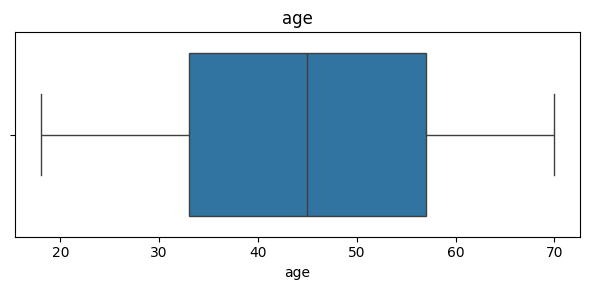

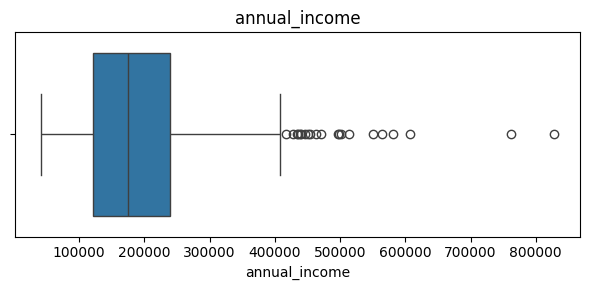

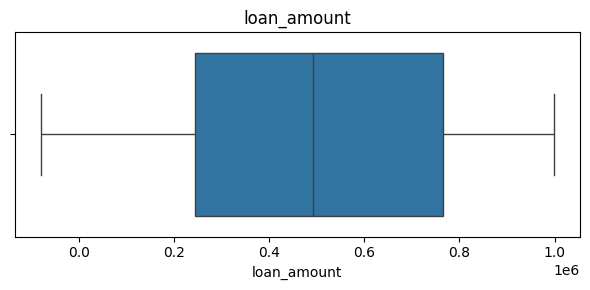

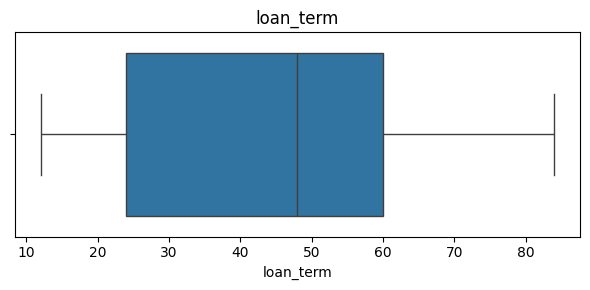

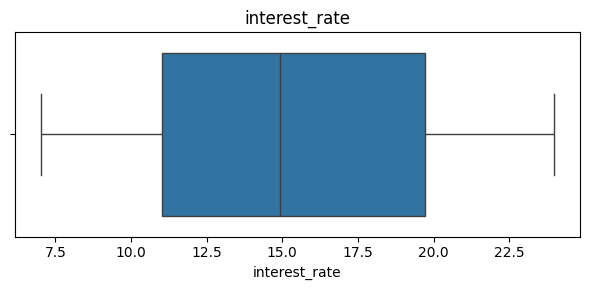

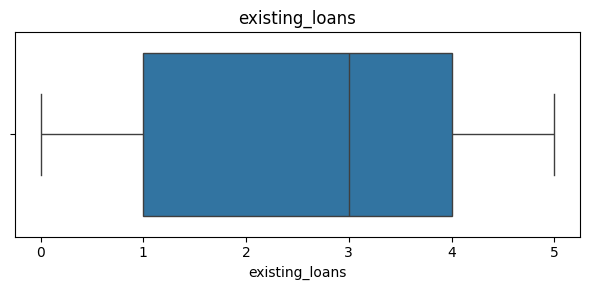

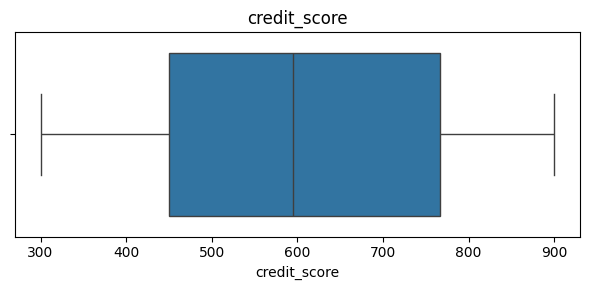

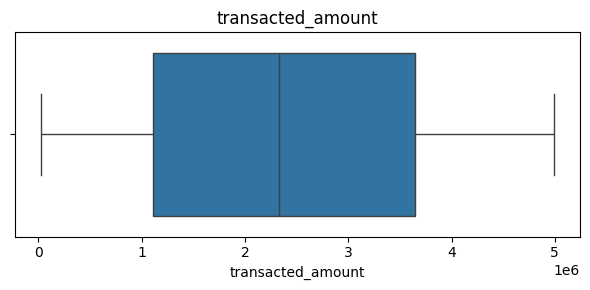

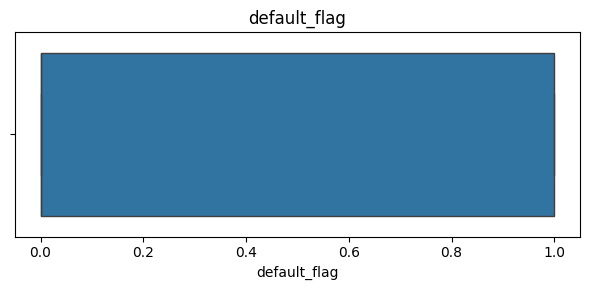

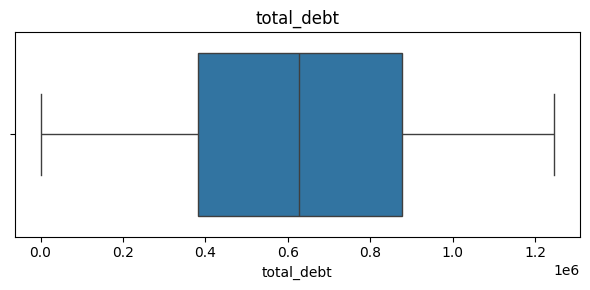

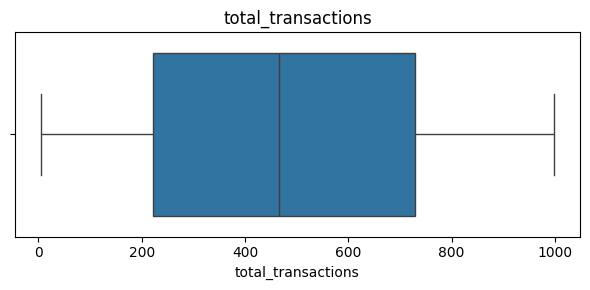

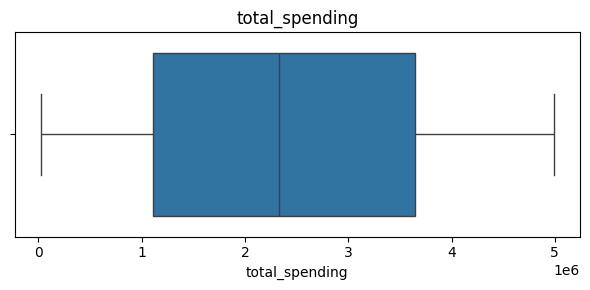

Z-score outliers: 7
IQR outliers: 21
Percentile outliers: 51
z_score        7
iqr           21
percentile    51
dtype: int64


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
df_num = df[numeric_cols]

# Boxplots
%matplotlib inline
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df_num[col])
    plt.title(f"{col}")
    plt.tight_layout()
    plt.show()

# Z-score
z_scores = np.abs(stats.zscore(df_num, nan_policy="omit"))
outliers_z = (z_scores > 3).any(axis=1)
print("Z-score outliers:", outliers_z.sum())

# IQR
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

outliers_iqr = ((df_num < lower_iqr) | (df_num > upper_iqr)).any(axis=1)
print("IQR outliers:", outliers_iqr.sum())

# Percentile
lower_p = df_num.quantile(0.01)
upper_p = df_num.quantile(0.99)

outliers_p = ((df_num < lower_p) | (df_num > upper_p)).any(axis=1)
print("Percentile outliers:", outliers_p.sum())

# Combine
outlier_flags = pd.DataFrame({
    "z_score": outliers_z,
    "iqr": outliers_iqr,
    "percentile": outliers_p
}, index=df.index)

print(outlier_flags.sum())

# Winsorization
df_winsorized = df.copy()
df_winsorized[numeric_cols] = df_num.apply(
    lambda col: stats.mstats.winsorize(col, limits=[0.01, 0.01])
)

df = df_winsorized.copy()

### Part E: Feature Engineering

In [13]:
# Handle Variable Types
# Mixed Variables (numeric + categorical) (none)
# Date & Time variables -> extract Year, Month, Day, Weekday
df["join_year"] = pd.to_datetime(df["join_date"]).dt.year
df["join_month"] = pd.to_datetime(df["join_date"]).dt.month
df["join_day"] = pd.to_datetime(df["join_date"]).dt.day
df["join_weekday"] = pd.to_datetime(df["join_date"]).dt.weekday

df[["join_date", "join_year", "join_month", "join_day", "join_weekday"]]

,join_date,join_year,join_month,join_day,join_weekday
0,2020-04-01,2020,4,1,2
1,2019-04-13,2019,4,13,5
2,2022-01-31,2022,1,31,0
3,2021-09-30,2021,9,30,3
4,2021-07-03,2021,7,3,5
...,...,...,...,...,...
495,2023-08-31,2023,8,31,3
496,2019-09-13,2019,9,13,4
497,2021-04-27,2021,4,27,1
498,2023-09-17,2023,9,17,6


In [14]:
# Encoding Categorical Variables
# Ordinal Encoding (education levels)
ordinal_encoder_education_level = sk.preprocessing.OrdinalEncoder(
    categories=[["High School", "Diploma", "Bachelors", "Masters", "PhD"]]
)
df["education_level_encoded"] = ordinal_encoder_education_level.fit_transform(
    df[["education_level"]]
)
# Label Encoding (binary features)
label_encoder_binary = sk.preprocessing.LabelEncoder()
df["gender_encoded"] = label_encoder_binary.fit_transform(df["gender"])
# One-Hot Encoding (region, loan_purpose)
onehot_encoder_region = sk.preprocessing.OneHotEncoder(sparse_output=False, drop="first")
encoded_region = onehot_encoder_region.fit_transform(df[["region"]])
encoded_region_df = pd.DataFrame(
    encoded_region, columns=onehot_encoder_region.get_feature_names_out(["region"]), index=df.index
)
onehot_encoder_loan_purpose = sk.preprocessing.OneHotEncoder(sparse_output=False, drop="first")
encoded_loan_purpose = onehot_encoder_loan_purpose.fit_transform(df[["loan_purpose"]])
encoded_loan_purpose_df = pd.DataFrame(
    encoded_loan_purpose, columns=onehot_encoder_loan_purpose.get_feature_names_out(["loan_purpose"]), index=df.index
)
df = pd.concat([df, encoded_region_df, encoded_loan_purpose_df], axis=1)

# Print
df[["education_level", "education_level_encoded", "gender", "gender_encoded", "region", "region_East", "region_North", "region_South", "region_West", "loan_purpose_Education", "loan_purpose_Home", "loan_purpose_Personal", "loan_purpose_Unknown"]].head()


,education_level,education_level_encoded,gender,gender_encoded,region,region_East,region_North,region_South,region_West,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_purpose_Unknown
0,High School,0.0,Male,1,Central,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,Bachelors,2.0,Male,1,North,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Bachelors,2.0,Male,1,Central,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,Diploma,1.0,Male,1,North,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,Diploma,1.0,Female,0,South,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [15]:
# Encoding Numerical Features
# Binning (discretize annual_income into groups)
kbins_annual_income = sk.preprocessing.KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile", quantile_method="averaged_inverted_cdf")
df["annual_income_binned"] = kbins_annual_income.fit_transform(df[["annual_income"]])
# Binarization (flag if > threshold)
binarizer_annual_income = sk.preprocessing.Binarizer(threshold=50000)
df["annual_income_high"] = binarizer_annual_income.fit_transform(df[["annual_income"]])
# Quantile Binning
quantile_binner = sk.preprocessing.KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile", quantile_method="averaged_inverted_cdf")
df["annual_income_quantile_binned"] = quantile_binner.fit_transform(df[["annual_income"]])
# K-Means Binning
kmeans_binner = sk.preprocessing.KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="kmeans")
df["annual_income_kmeans_binned"] = kmeans_binner.fit_transform(df[["annual_income"]])

df[["annual_income", "annual_income_binned", "annual_income_high", "annual_income_quantile_binned", "annual_income_kmeans_binned"]].head()

,annual_income,annual_income_binned,annual_income_high,annual_income_quantile_binned,annual_income_kmeans_binned
0,108490.0,0.0,1.0,0.0,0.0
1,259670.0,4.0,1.0,4.0,2.0
2,275080.0,4.0,1.0,4.0,2.0
3,81610.0,0.0,1.0,0.0,0.0
4,48410.0,0.0,0.0,0.0,0.0


### Part F: Feature Scaling

In [16]:
# Apply multiple scaling methods:
scaled_datasets = []
# Standardization (Z-score scaling)
scaler_standard = sk.preprocessing.StandardScaler()
scaled_datasets.append({"Standard": scaler_standard.fit_transform(df[["annual_income"]])})
# Normalization (Min-Max Scaling)
scaler_minmax = sk.preprocessing.MinMaxScaler()
scaled_datasets.append({"MinMax":scaler_minmax.fit_transform(df[["annual_income"]])})
# MaxAbs Scaling
scaler_maxabs = sk.preprocessing.MaxAbsScaler()
scaled_datasets.append({"MaxAbs":scaler_maxabs.fit_transform(df[["annual_income"]])})
# Robust Scaling
scaler_robust = sk.preprocessing.RobustScaler()
scaled_datasets.append({"Robust":scaler_robust.fit_transform(df[["annual_income"]])})

# Set Standardization as the final scaled dataset for further analysis
df["annual_income_scaled"] = scaler_standard.transform(df[["annual_income"]]).flatten()

# Compare scaling methods
for method in scaled_datasets:
    name, scaled_data = list(method.items())[0]
    print(f"Scaling Method: {name}")
    print(f"Mean: {scaled_data.mean():.4f}, Std: {scaled_data.std():.4f}")
    print(f"Min: {scaled_data.min():.4f}, Max: {scaled_data.max():.4f}\n")

Scaling Method: Standard
Mean: 0.0000, Std: 1.0000
Min: -1.4614, Max: 3.6659

Scaling Method: MinMax
Mean: 0.2850, Std: 0.1950
Min: 0.0000, Max: 1.0000

Scaling Method: MaxAbs
Mean: 0.3479, Std: 0.1779
Min: 0.0879, Max: 1.0000

Scaling Method: Robust
Mean: 0.1370, Std: 0.8355
Min: -1.0839, Max: 3.1998



### Part G: Feature Construction and Transformation

In [17]:
# Apply Transformations
# FuncttionTransformer -> log transform, reciprocal, square root
log_transformer = sk.preprocessing.FunctionTransformer(func=np.log1p)
df["annual_income_log"] = log_transformer.fit_transform(df[["annual_income"]])
# PowerTransformer -> Box-Cox and Yeo-Johnson
power_transformer_yeo_johnson = sk.preprocessing.PowerTransformer(method="yeo-johnson")
df["annual_income_yeo_johnson"] = power_transformer_yeo_johnson.fit_transform(df[["annual_income"]])
power_transformer_box_cox = sk.preprocessing.PowerTransformer(method="box-cox")
df["annual_income_box_cox"] = power_transformer_box_cox.fit_transform(df[["annual_income"]])
# ColumnTransformer -> apply different preprocessing steps to different columns.
column_transformer = sk.compose.ColumnTransformer(
    transformers=[
        ("log", log_transformer, ["annual_income"]),
        ("yeo_johnson", power_transformer_yeo_johnson, ["annual_income"]),
        ("box_cox", power_transformer_box_cox, ["annual_income"])
    ]
)
transformed_data = column_transformer.fit_transform(df)
df["annual_income_log_col"] = transformed_data[:, 0]
df["annual_income_yeo_johnson_col"] = transformed_data[:, 1]
df["annual_income_box_cox_col"] = transformed_data[:, 2]

print(df[["annual_income", "annual_income_log", "annual_income_yeo_johnson", "annual_income_box_cox", "annual_income_log_col", "annual_income_yeo_johnson_col", "annual_income_box_cox_col"]].head())

   annual_income  annual_income_log  annual_income_yeo_johnson  \
0       108490.0          11.594422                  -0.902507   
1       259670.0          12.467171                   0.853904   
2       275080.0          12.524821                   0.972757   
3        81610.0          11.309719                  -1.458437   
4        48410.0          10.787482                  -2.457031   

   annual_income_box_cox  annual_income_log_col  \
0              -0.902506              11.594422   
1               0.853904              12.467171   
2               0.972757              12.524821   
3              -1.458437              11.309719   
4              -2.457034              10.787482   

   annual_income_yeo_johnson_col  annual_income_box_cox_col  
0                      -0.902507                  -0.902506  
1                       0.853904                   0.853904  
2                       0.972757                   0.972757  
3                      -1.458437                

In [18]:
# Construct new features
# Debt-to-Income Ratio
df["debt_to_income_ratio"] = df["total_debt"] / (df["annual_income"] + 1)
# Average monthly transactions
df["avg_monthly_transaction"] = df["total_transactions"] / 12
# Spending-to-Income Ratio
df["spending_to_income_ratio"] = df["total_spending"] / (df["annual_income"] + 1)

df[["total_debt", "annual_income", "debt_to_income_ratio", "total_transactions", "avg_monthly_transaction", "total_spending", "spending_to_income_ratio"]].head()

,total_debt,annual_income,debt_to_income_ratio,total_transactions,avg_monthly_transaction,total_spending,spending_to_income_ratio
0,896294.63,108490.0,8.261465,882.0,73.500000,4414251.13,40.687717
1,981994.67,259670.0,3.781688,98.0,8.166667,493924.02,1.902115
2,757366.20,275080.0,2.753248,57.0,4.750000,287977.11,1.046881
3,495645.90,81610.0,6.073273,130.0,10.833333,654826.76,8.023756
4,263672.55,48410.0,5.446542,59.0,4.916667,298127.99,6.158270


### Part H: Final Delivarable

In [19]:
# Provide a final cleaned and transformed dataset
# CSV
df.to_csv("./data/credit_risk_dataset_cleaned.csv", index=False)
# JSON
df.to_json("./data/credit_risk_dataset_cleaned.json", orient="records", lines=True)

The report is written in a markdown format file named [report.md](./report.md)